In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

## 1. Load Training Data

Train on 2021 Q1-Q3, test on 2021 Q4

In [20]:
df_train = pd.read_csv('../data/processed/procurement_train.csv')
df_test = pd.read_csv('../data/processed/procurement_test.csv')

print(f"📊 Training data: {len(df_train):,} rows × {len(df_train.columns)} columns")
print(f"📊 Test data: {len(df_test):,} rows × {len(df_test.columns)} columns")

df_train.head()

📊 Training data: 82,057 rows × 21 columns
📊 Test data: 47,394 rows × 21 columns


,Approved Budget of the Contract,Contract Amount,price_variance_pct,bidding_duration_days,award_speed_days,Contract Duration,Procurement Mode,Funding Instrument,Region,Awardee Size,item_count,unique_unspsc_count,Bid Reference No.,Procuring Entity (PE),Awardee Organization Name,Notice Title,UNSPSC Code,UNSPSC Description,Published Date,Closing Date,Award Date
0,293001.0,289845.0,-1.077129,7,5,10,Public Bidding,Budget for the Contract Approved by the Sanggu...,Region VI,Micro,3,1,8062667,"BARANGAY SANGCATE, SANTA BARBARA, ILOILO",VEONG CONSTRUCTION & SUPPLY,IMPROVEMENT OF MPH,1,Temporary construction and maintenance support...,2024-11-14,2024-11-21,2024-11-26
1,479400.0,337800.0,-29.536921,151,103,30,Negotiated Procurement - Small Value Procureme...,Corporate Budget for the Contract Approved by ...,Region VIII,Micro,3,1,10558411,GOVERNMENT SERVICE INSURANCE SYSTEM - TACLOBAN...,BURGOSCO AUTO AND TRUCK PARTS OUTLET,Request for Quotation_Purchase of Tire,1,Tires and tire tubes,2024-02-10,2024-07-10,2024-10-21
2,450000.0,444000.0,-1.333333,3,1,0,Negotiated Procurement - Small Value Procureme...,General Appropriations Act,Region IX,Micro,3,1,11008541,DEPARTMENT OF SOCIAL WELFARE AND DEVELOPMENT -...,LUCKY 8 MARKETING,PAG-ABOT-2024-12-O1435 - Glass Partition for t...,1,Hardware,2024-12-14,2024-12-17,2024-12-18
3,660000.0,477600.0,-27.636364,3,3,30,Negotiated Procurement - Small Value Procureme...,General Appropriations Act,Caraga,Micro,3,1,11100112,NATIONAL IRRIGATION ADMINISTRATION - IMO AGUSA...,JB COMPUTERS & CCTV INSTALLATION SERVICES,SUPPLY AND DELIVERY OF IT EQUIPMENTS,1,Information Technology Broadcasting and Teleco...,2024-10-15,2024-10-18,2024-10-21
4,1700979.0,1682550.0,-1.083435,7,27,0,Negotiated Procurement - Small Value Procureme...,General Appropriations Act,Region II,Micro,3,1,11151565,DEPARTMENT OF ENVIRONMENT AND NATURAL RES. - P...,FVA TRADING,SUPPLY AND DELIVERY OF HARDWARE AND CONSTRUCTI...,1,Hardware,2024-10-18,2024-10-25,2024-11-21


In [21]:
print("Training data info:")
df_train.info()

Training data info:
<class 'pandas.DataFrame'>
RangeIndex: 82057 entries, 0 to 82056
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Approved Budget of the Contract  82057 non-null  float64
 1   Contract Amount                  82057 non-null  float64
 2   price_variance_pct               82057 non-null  float64
 3   bidding_duration_days            82057 non-null  int64  
 4   award_speed_days                 82057 non-null  int64  
 5   Contract Duration                82057 non-null  int64  
 6   Procurement Mode                 82057 non-null  str    
 7   Funding Instrument               82057 non-null  str    
 8   Region                           82057 non-null  str    
 9   Awardee Size                     79760 non-null  str    
 10  item_count                       82057 non-null  int64  
 11  unique_unspsc_count              82057 non-null  int64  
 12  Bid Refer

## 2. Feature Selection

**8 Numerical** + **4 Categorical (encoded)** = **12 features**

In [22]:
numerical_features = [
    'Approved Budget of the Contract',   # Raw amount
    'Contract Amount',                    # Raw amount  
    'price_variance_pct',                  # Derived ratio
    'bidding_duration_days',                     # Days
    'award_speed_days',                     # Days
    'Contract Duration',                     # Days
    'item_count',                        # Count
    'unique_unspsc_count'                      # Count
]

categorical_features = [
    'Procurement Mode',     # 8 categories
    'Funding Instrument',     # 6 categories
    'Region',                  # 18 categories
    'Awardee Size'             # 5 categories
]

print(f"Numerical: {len(numerical_features)}")
print(f"Categorical: {len(categorical_features)}")
print(f"Total: {len(numerical_features) + len(categorical_features)}")

Numerical: 8
Categorical: 4
Total: 12


In [23]:
# Encode categorical features (FIT on train)
label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    df_train[col] = df_train[col].fillna('UNKNOWN')
    df_train[f'{col}_encoded'] = le.fit_transform(df_train[col])
    label_encoders[col] = le

encoded_features = [f'{col}_encoded' for col in categorical_features]

print("✓ Training data encoding complete")
for col in categorical_features:
    n_categories = df_train[f'{col}_encoded'].nunique()
    print(f"  {col}: {n_categories} categories")

✓ Training data encoding complete
  Procurement Mode: 8 categories
  Funding Instrument: 6 categories
  Region: 18 categories
  Awardee Size: 5 categories


In [24]:
feature_columns = numerical_features + encoded_features
X_train = df_train[feature_columns].copy()

print(f"✓ Training feature matrix: {X_train.shape}")

✓ Training feature matrix: (82057, 12)


## 3. Feature Scaling (FIT on train)

In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

print(f"✓ Scaled training data: {X_train_scaled.shape}")

✓ Scaled training data: (82057, 12)


## 4. Train Isolation Forest

Train on 2021 Q1-Q3 data

In [26]:
iso_forest = IsolationForest(
    contamination='auto',
    random_state=42,
    n_estimators=200,
    max_samples='auto',
    n_jobs=-1
)

print(f"Training on {len(X_train_scaled):,} contracts...")
iso_forest.fit(X_train_scaled)

# Get training scores
train_scores = iso_forest.score_samples(X_train_scaled)
df_train['anomaly_score'] = train_scores

print(f"✓ Complete")
print(f"Training score range: [{train_scores.min():.3f}, {train_scores.max():.3f}]")
print(f"Mean: {train_scores.mean():.3f}, Std: {train_scores.std():.3f}")
print(f"\nPercentiles:")
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"  {p:2d}%: {np.percentile(train_scores, p):.3f}")

Training on 82,057 contracts...
✓ Complete
Training score range: [-0.793, -0.349]
Mean: -0.418, Std: 0.063

Percentiles:
   1%: -0.638
   5%: -0.553
  10%: -0.506
  25%: -0.440
  50%: -0.398
  75%: -0.373
  90%: -0.361
  95%: -0.355
  99%: -0.352


## 5. Score TEST Data

In [27]:
# Encode test data using FITTED encoders
for col in categorical_features:
    df_test[col] = df_test[col].fillna('UNKNOWN')
    # Handle unseen categories
    le = label_encoders[col]
    df_test[f'{col}_encoded'] = df_test[col].map(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

X_test = df_test[feature_columns].copy()
X_test_scaled = scaler.transform(X_test)  # TRANSFORM only, don't fit

# Get test scores
test_scores = iso_forest.score_samples(X_test_scaled)
df_test['anomaly_score'] = test_scores

print(f"✓ Test data scored: {len(test_scores):,} contracts")
print(f"Test score range: [{test_scores.min():.3f}, {test_scores.max():.3f}]")
print(f"Mean: {test_scores.mean():.3f}, Std: {test_scores.std():.3f}")

✓ Test data scored: 47,394 contracts
Test score range: [-0.776, -0.349]
Mean: -0.418, Std: 0.050


## 6. Rank & Classify Risk Tiers

Lower score = more anomalous = higher risk

In [28]:
# Lower score = more anomalous = higher risk
df_train_ranked = df_train.sort_values('anomaly_score').reset_index(drop=True)
df_train_ranked['audit_rank'] = range(1, len(df_train_ranked) + 1)

# Dynamic thresholds from TRAINING percentiles
RISK_THRESHOLDS = {
    'HIGH': np.percentile(train_scores, 5),      # Top 5% most unusual
    'MEDIUM': np.percentile(train_scores, 15),   # Next 10% unusual
    'LOW': np.percentile(train_scores, 35)       # Next 20% somewhat unusual
    # Rest are NORMAL
}

print("="*60)
print("RISK TIER THRESHOLDS (from TRAINING data)")
print("="*60)
print(f"  HIGH:   < {RISK_THRESHOLDS['HIGH']:.3f}   (top 5% most unusual)")
print(f"  MEDIUM: < {RISK_THRESHOLDS['MEDIUM']:.3f} (next 10% unusual)")
print(f"  LOW:    < {RISK_THRESHOLDS['LOW']:.3f}    (next 20% somewhat unusual)")
print(f"  NORMAL: >= {RISK_THRESHOLDS['LOW']:.3f}   (remaining 65% typical)")

def assign_risk_tier(score):
    """Assign risk tier based on percentile thresholds from TRAINING."""
    if score < RISK_THRESHOLDS['HIGH']:
        return 'HIGH'      # Most unusual patterns
    elif score < RISK_THRESHOLDS['MEDIUM']:
        return 'MEDIUM'    # Unusual patterns  
    elif score < RISK_THRESHOLDS['LOW']:
        return 'LOW'       # Somewhat unusual
    else:
        return 'NORMAL'    # Typical patterns

# Apply to training data
df_train_ranked['risk_tier'] = df_train_ranked['anomaly_score'].apply(assign_risk_tier)

print("\n📊 TRAINING DATA RISK DISTRIBUTION:")
print("-" * 40)
tier_counts = df_train_ranked['risk_tier'].value_counts()
for tier in ['HIGH', 'MEDIUM', 'LOW', 'NORMAL']:
    count = tier_counts.get(tier, 0)
    pct = count / len(df_train_ranked) * 100
    score_min = df_train_ranked[df_train_ranked['risk_tier']==tier]['anomaly_score'].min()
    score_max = df_train_ranked[df_train_ranked['risk_tier']==tier]['anomaly_score'].max()
    print(f"  {tier:6s}: {count:5,} ({pct:4.1f}%) | scores [{score_min:.3f}, {score_max:.3f}]")

RISK TIER THRESHOLDS (from TRAINING data)
  HIGH:   < -0.553   (top 5% most unusual)
  MEDIUM: < -0.475 (next 10% unusual)
  LOW:    < -0.419    (next 20% somewhat unusual)
  NORMAL: >= -0.419   (remaining 65% typical)

📊 TRAINING DATA RISK DISTRIBUTION:
----------------------------------------
  HIGH  : 4,103 ( 5.0%) | scores [-0.793, -0.553]
  MEDIUM: 8,206 (10.0%) | scores [-0.553, -0.475]
  LOW   : 16,411 (20.0%) | scores [-0.475, -0.419]
  NORMAL: 53,337 (65.0%) | scores [-0.419, -0.349]


## 7. Apply Risk Tiers to TEST Data

In [29]:
# Use thresholds from training to classify test data
df_test_ranked = df_test.sort_values('anomaly_score').reset_index(drop=True)
df_test_ranked['audit_rank'] = range(1, len(df_test_ranked) + 1)
df_test_ranked['risk_tier'] = df_test_ranked['anomaly_score'].apply(assign_risk_tier)

print("\n" + "="*60)
print("📊 TEST DATA RISK DISTRIBUTION")
print("="*60)
print(f"Test contracts: {len(df_test_ranked):,}")
print("-" * 40)

tier_counts_test = df_test_ranked['risk_tier'].value_counts()
for tier in ['HIGH', 'MEDIUM', 'LOW', 'NORMAL']:
    count = tier_counts_test.get(tier, 0)
    pct = count / len(df_test_ranked) * 100
    score_min = df_test_ranked[df_test_ranked['risk_tier']==tier]['anomaly_score'].min()
    score_max = df_test_ranked[df_test_ranked['risk_tier']==tier]['anomaly_score'].max()
    print(f"  {tier:6s}: {count:5,} ({pct:4.1f}%) | scores [{score_min:.3f}, {score_max:.3f}]")

# Compare with expected (training distribution)
print("\n📈 EXPECTED VS ACTUAL (Test Data):")
print("-" * 40)
for tier in ['HIGH', 'MEDIUM', 'LOW']:
    expected_pct = 5 if tier == 'HIGH' else 10 if tier == 'MEDIUM' else 20
    actual_pct = tier_counts_test.get(tier, 0) / len(df_test_ranked) * 100
    diff = actual_pct - expected_pct
    print(f"  {tier:6s}: Expected {expected_pct:2d}%, Actual {actual_pct:4.1f}% ({diff:+.1f}% diff)")


📊 TEST DATA RISK DISTRIBUTION
Test contracts: 47,394
----------------------------------------
  HIGH  : 1,152 ( 2.4%) | scores [-0.776, -0.553]
  MEDIUM: 4,320 ( 9.1%) | scores [-0.553, -0.475]
  LOW   : 13,562 (28.6%) | scores [-0.475, -0.419]
  NORMAL: 28,360 (59.8%) | scores [-0.419, -0.349]

📈 EXPECTED VS ACTUAL (Test Data):
----------------------------------------
  HIGH  : Expected  5%, Actual  2.4% (-2.6% diff)
  MEDIUM: Expected 10%, Actual  9.1% (-0.9% diff)
  LOW   : Expected 20%, Actual 28.6% (+8.6% diff)


## 8. High-Risk vs Normal Comparison

In [30]:
high_risk = df_test_ranked[df_test_ranked['risk_tier'].isin(['HIGH'])]
normal = df_test_ranked[df_test_ranked['risk_tier'] == 'NORMAL']

print("\n" + "="*60)
print("🔴 HIGH-RISK vs NORMAL COMPARISON (TEST DATA)")
print("="*60)
print(f"\nCounts:")
print(f"  High-Risk: {len(high_risk):,}")
print(f"  Normal: {len(normal):,}")

print(f"\nMedian Contract Amount:")
print(f"  High-Risk: ₱{high_risk['Contract Amount'].median():,.0f}")
print(f"  Normal: ₱{normal['Contract Amount'].median():,.0f}")

print(f"\nMedian Price Variance:")
print(f"  High-Risk: {high_risk['price_variance_pct'].median():.1f}%")
print(f"  Normal: {normal['price_variance_pct'].median():.1f}%")

# Procurement mode comparison
print("\n🏢 TOP PROCUREMENT MODES:")
print("High-Risk:")
for mode, count in high_risk['Procurement Mode'].value_counts().head(3).items():
    pct = count / len(high_risk) * 100
    print(f"  {mode}: {count} ({pct:.1f}%)")
    
print("Normal:")
for mode, count in normal['Procurement Mode'].value_counts().head(3).items():
    pct = count / len(normal) * 100
    print(f"  {mode}: {count} ({pct:.1f}%)")


🔴 HIGH-RISK vs NORMAL COMPARISON (TEST DATA)

Counts:
  High-Risk: 1,152
  Normal: 28,360

Median Contract Amount:
  High-Risk: ₱20,523,746
  Normal: ₱251,866

Median Price Variance:
  High-Risk: -69.3%
  Normal: -0.4%

🏢 TOP PROCUREMENT MODES:
High-Risk:
  Public Bidding: 807 (70.1%)
  Negotiated Procurement - Small Value Procurement (Sec. 53.9): 211 (18.3%)
  Shopping - Ordinary/Regular Office Supplies & Equipment (Sec. 52.1.b): 123 (10.7%)
Normal:
  Negotiated Procurement - Small Value Procurement (Sec. 53.9): 17288 (61.0%)
  Public Bidding: 9717 (34.3%)
  Shopping - Ordinary/Regular Office Supplies & Equipment (Sec. 52.1.b): 1074 (3.8%)


## 9. Detailed Statistics by Risk Tier (TEST DATA)

In [31]:
print("\nTier Characteristics:")
print("\n" + "="*60)
print("📊 DETAILED STATISTICS BY RISK TIER (TEST DATA)")
print("="*60)

for tier in ['HIGH', 'MEDIUM', 'LOW', 'NORMAL']:
    tier_data = df_test_ranked[df_test_ranked['risk_tier'] == tier]
    if len(tier_data) == 0:
        continue
    
    print(f"\n{tier} TIER ({len(tier_data):,} contracts):")
    print(tier_data[['Contract Amount', 'price_variance_pct', 
                     'bidding_duration_days', 'award_speed_days']].describe())


Tier Characteristics:

📊 DETAILED STATISTICS BY RISK TIER (TEST DATA)

HIGH TIER (1,152 contracts):
       Contract Amount  price_variance_pct  bidding_duration_days  \
count     1.152000e+03         1152.000000            1152.000000   
mean      3.196892e+08          -52.637053             190.584201   
std       1.511092e+09           41.527761              91.581272   
min       2.000000e+00         -100.000000               4.000000   
25%       4.552200e+05          -92.436292             123.750000   
50%       2.052375e+07          -69.338055             201.000000   
75%       1.536471e+08           -2.578782             268.000000   
max       2.023872e+10            0.000000             353.000000   

       award_speed_days  
count       1152.000000  
mean          52.714410  
std           49.142933  
min            0.000000  
25%           15.000000  
50%           42.000000  
75%           79.000000  
max          399.000000  

MEDIUM TIER (4,320 contracts):
       Cont

## 10. Visualizations

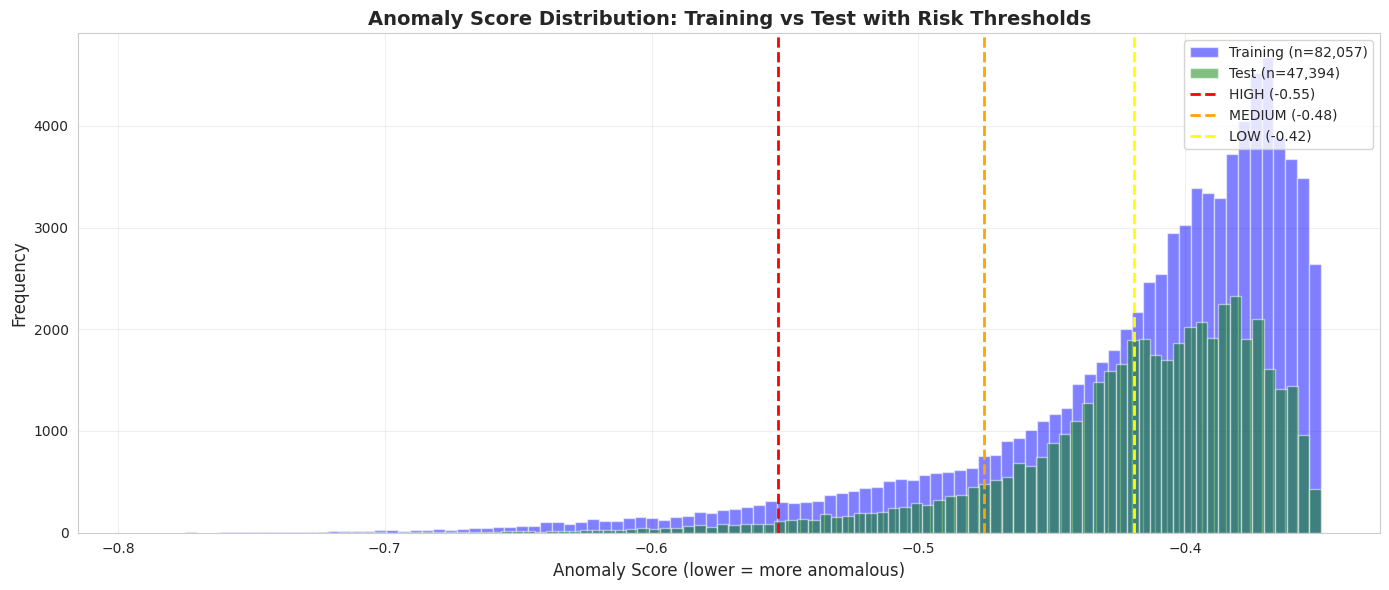

In [32]:
# Define colors for risk tiers
tier_colors = {'HIGH': 'red', 'MEDIUM': 'orange', 'LOW': 'yellow', 'NORMAL': 'lightblue'}
tier_order = ['HIGH', 'MEDIUM', 'LOW', 'NORMAL']

# Plot 1: Score Distribution
plt.figure(figsize=(14, 6))

plt.hist(train_scores, bins=100, alpha=0.5, label=f'Training (n={len(train_scores):,})', color='blue')
plt.hist(test_scores, bins=100, alpha=0.5, label=f'Test (n={len(test_scores):,})', color='green')

for tier, color in tier_colors.items():
    if tier in RISK_THRESHOLDS:
        threshold = RISK_THRESHOLDS[tier]
        plt.axvline(threshold, color=color, linestyle='--', linewidth=2, 
                    label=f'{tier} ({threshold:.2f})')

plt.xlabel('Anomaly Score (lower = more anomalous)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Anomaly Score Distribution: Training vs Test with Risk Thresholds', fontsize=14, fontweight='bold')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_67756/2447595123.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(tier_data_list, labels=tier_labels, patch_artist=True)


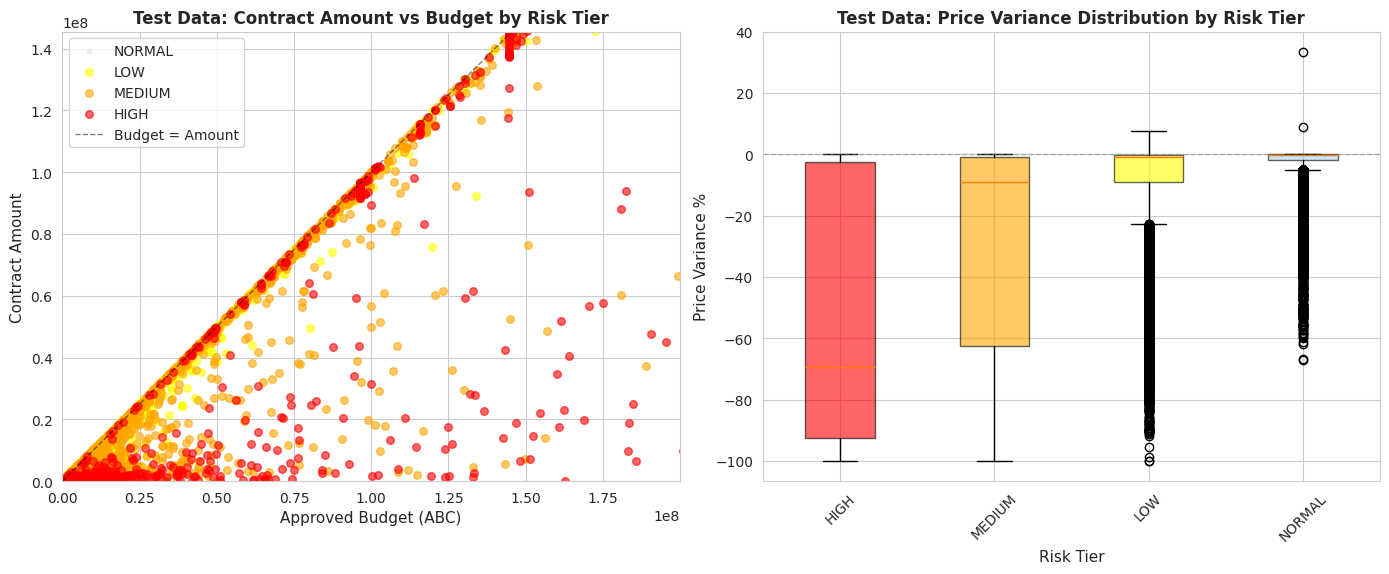

In [33]:
# Plot 2: Contract Amount vs Budget by Risk Tier (TEST DATA)
plt.figure(figsize=(14, 6))

# Plot each tier
for tier in ['NORMAL', 'LOW', 'MEDIUM', 'HIGH']:  # Plot in reverse order so high-risk appears on top
    tier_data = df_test_ranked[df_test_ranked['risk_tier'] == tier]
    if len(tier_data) == 0:
        continue
    
    alpha = 0.3 if tier == 'NORMAL' else 0.6
    size = 10 if tier == 'NORMAL' else 30
    
    plt.subplot(1, 2, 1)
    plt.scatter(
        tier_data['Approved Budget of the Contract'],
        tier_data['Contract Amount'],
        alpha=alpha, s=size, label=tier, color=tier_colors[tier]
    )

# Add budget = amount line
max_val = df_test_ranked['Approved Budget of the Contract'].quantile(0.99)
plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='Budget = Amount', linewidth=1)
plt.xlabel('Approved Budget (ABC)', fontsize=11)
plt.ylabel('Contract Amount', fontsize=11)
plt.title('Test Data: Contract Amount vs Budget by Risk Tier', fontsize=12, fontweight='bold')
plt.legend()
plt.xlim(0, max_val)
plt.ylim(0, df_test_ranked['Contract Amount'].quantile(0.99))

# Price variance boxplot by tier
plt.subplot(1, 2, 2)
tier_data_list = [df_test_ranked[df_test_ranked['risk_tier'] == tier]['price_variance_pct'].values 
                  for tier in tier_order if len(df_test_ranked[df_test_ranked['risk_tier'] == tier]) > 0]
tier_labels = [tier for tier in tier_order if len(df_test_ranked[df_test_ranked['risk_tier'] == tier]) > 0]

bp = plt.boxplot(tier_data_list, labels=tier_labels, patch_artist=True)
for patch, tier in zip(bp['boxes'], tier_labels):
    patch.set_facecolor(tier_colors[tier])
    patch.set_alpha(0.6)

plt.ylabel('Price Variance %', fontsize=11)
plt.xlabel('Risk Tier', fontsize=11)
plt.title('Test Data: Price Variance Distribution by Risk Tier', fontsize=12, fontweight='bold')
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

/tmp/ipykernel_67756/1692204728.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(bidding_data, labels=tier_labels, patch_artist=True)
/tmp/ipykernel_67756/1692204728.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(award_data, labels=tier_labels, patch_artist=True)


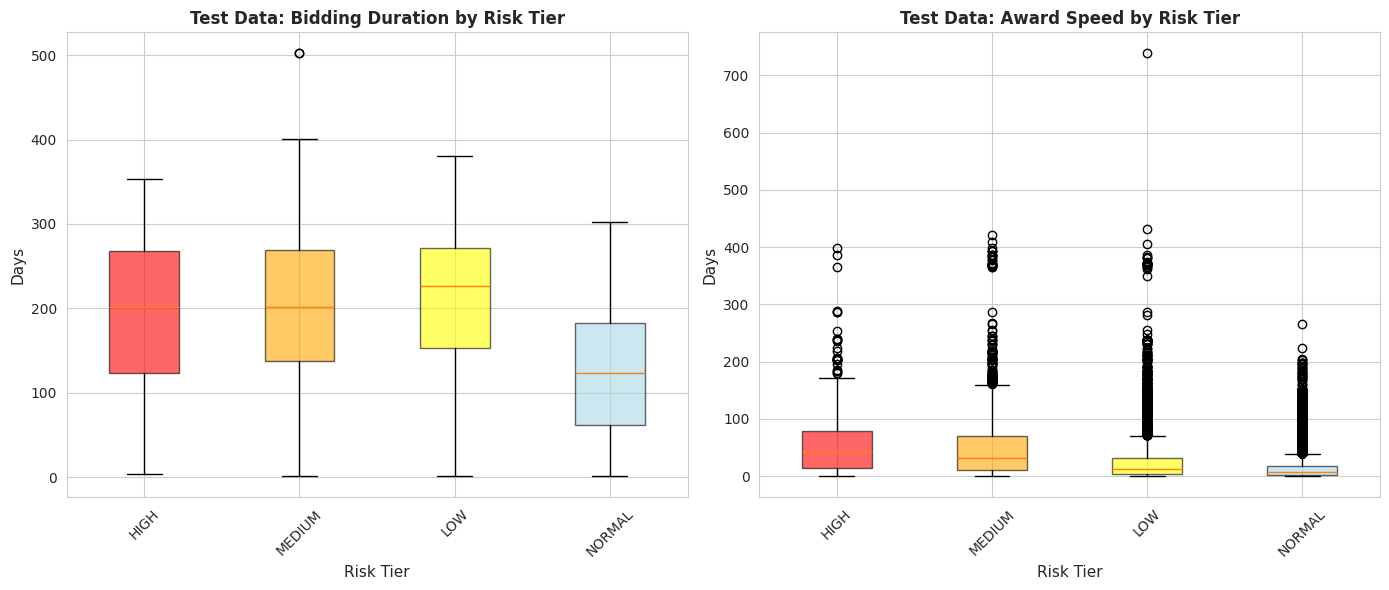

In [34]:
# Plot 3: Timeline features by risk tier (TEST DATA)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bidding duration
bidding_data = [df_test_ranked[df_test_ranked['risk_tier'] == tier]['bidding_duration_days'].values 
                for tier in tier_order if len(df_test_ranked[df_test_ranked['risk_tier'] == tier]) > 0]
tier_labels = [tier for tier in tier_order if len(df_test_ranked[df_test_ranked['risk_tier'] == tier]) > 0]

bp1 = axes[0].boxplot(bidding_data, labels=tier_labels, patch_artist=True)
for patch, tier in zip(bp1['boxes'], tier_labels):
    patch.set_facecolor(tier_colors[tier])
    patch.set_alpha(0.6)
axes[0].set_ylabel('Days', fontsize=11)
axes[0].set_xlabel('Risk Tier', fontsize=11)
axes[0].set_title('Test Data: Bidding Duration by Risk Tier', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Award speed
award_data = [df_test_ranked[df_test_ranked['risk_tier'] == tier]['award_speed_days'].values 
              for tier in tier_order if len(df_test_ranked[df_test_ranked['risk_tier'] == tier]) > 0]

bp2 = axes[1].boxplot(award_data, labels=tier_labels, patch_artist=True)
for patch, tier in zip(bp2['boxes'], tier_labels):
    patch.set_facecolor(tier_colors[tier])
    patch.set_alpha(0.6)
axes[1].set_ylabel('Days', fontsize=11)
axes[1].set_xlabel('Risk Tier', fontsize=11)
axes[1].set_title('Test Data: Award Speed by Risk Tier', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 11. Save Results

In [35]:

# Create results directory
results_dir = Path('../results')
results_dir.mkdir(exist_ok=True)

# Save training results
train_output = results_dir / 'train_results.csv'
df_train_ranked[['audit_rank', 'risk_tier', 'Bid Reference No.', 'Procuring Entity (PE)', 
                 'Awardee Organization Name', 'Contract Amount', 'Approved Budget of the Contract', 
                 'price_variance_pct', 'Procurement Mode', 'Funding Instrument', 
                 'anomaly_score']].to_csv(train_output, index=False)

# Save test results
test_output = results_dir / 'test_results.csv'
df_test_ranked[['audit_rank', 'risk_tier', 'Bid Reference No.', 'Procuring Entity (PE)', 
                'Awardee Organization Name', 'Contract Amount', 'Approved Budget of the Contract', 
                'price_variance_pct', 'Procurement Mode', 'Funding Instrument', 
                'anomaly_score']].to_csv(test_output, index=False)

# Save audit priorities (HIGH and MEDIUM for review)
audit_priorities = df_test_ranked[df_test_ranked['risk_tier'].isin(['HIGH', 'MEDIUM'])]
audit_file = results_dir / 'audit_priorities.csv'
audit_priorities[['audit_rank', 'risk_tier', 'Bid Reference No.', 'Procuring Entity (PE)', 
                  'Awardee Organization Name', 'Notice Title', 
                  'Contract Amount', 'price_variance_pct', 'anomaly_score']].to_csv(audit_file, index=False)

print("\n" + "="*60)
print("✅ RESULTS SAVED")
print("="*60)
print(f"✓ Training results: {train_output}")
print(f"  {len(df_train_ranked):,} contracts")
print(f"\n✓ Test results: {test_output}")
print(f"  {len(df_test_ranked):,} contracts")
print(f"\n✓ Audit priorities (HIGH + MEDIUM): {audit_file}")
print(f"  {len(audit_priorities):,} contracts for review")

print("\n📋 AUDIT PRIORITIES BY TIER:")
for tier in ['HIGH', 'MEDIUM']:
    count = (audit_priorities['risk_tier'] == tier).sum()
    if count > 0:
        print(f"  {tier}: {count:,}")


✅ RESULTS SAVED
✓ Training results: ../results/train_results.csv
  82,057 contracts

✓ Test results: ../results/test_results.csv
  47,394 contracts

✓ Audit priorities (HIGH + MEDIUM): ../results/audit_priorities.csv
  5,472 contracts for review

📋 AUDIT PRIORITIES BY TIER:
  HIGH: 1,152
  MEDIUM: 4,320
